<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Decision Making with Business Statistics</center></font>
<center><font size=5>Week 4: Project: E-News Express</font></center>

## Define Problem Statement and Objectives

# Business Problem Statement

E‑News Express has experienced a decline in new monthly subscribers. Leadership believes that the current landing page fails to keep users engaged long enough due to its outdated layout, content structure, and recommendations.

The company needs to determine whether the old design negatively impacts engagement and conversion, and whether the new landing page can improve key performance metrics

# Project Objectives (EN)

The goal of this project is to evaluate the effectiveness of the new landing page and determine whether it improves user engagement and conversion. Specifically, the analysis aims to:

1. Assess user engagement
Determine whether users spend more time on the new landing page than on the old one.

2. Evaluate conversion performance
Check whether the conversion rate is higher for the new page.

3. Examine the impact of preferred language on conversion
Identify whether conversion likelihood depends on the user’s preferred language.

4. Assess time spent across language groups
Determine whether users of different languages spend similar or different amounts of time on the new page.

5. Provide business recommendations
Based on statistical evidence, advise whether the new page should be fully deployed and what areas require further optimization.

# Data Description

*The data contains information regarding the interaction of users in both groups with the two versions of the landing page.*


user_id - Unique user ID of the person visiting the website

group - Whether the user belongs to the first group (control) or the second group (treatment)

landing_page - Whether the landing page is new or old

time_spent_on_the_page - Time (in minutes) spent by the user on the landing page

converted - Whether the user gets converted to a subscriber of the news portal or not

language_preferred - Language chosen by the user to view the landing page

## Import all the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 81.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Reading the Data into a DataFrame

In [ ]:
df = pd.read_csv('abtest.csv')

## Explore the dataset and extract insights using Exploratory Data Analysis

# Data Overview

Viewing the first and last few rows of the dataset

Checking the shape of the dataset

Getting the statistical summary for the variables

Check for missing values

Check for duplicates




In [ ]:
# Viewing the first and last few rows of the dataset
display(df.head())

display(df.tail())


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [ ]:
# Checking the shape of the dataset
df.shape

(100, 6)

Reviewing the first and last few rows confirms that the dataset is structured properly: each row represents a unique user with a complete set of attributes. Both control (old page) and treatment (new page) groups are present.

The dataset shape (df.shape) shows 100 rows and 6 columns. This confirms that
# the data has been fully loaded
without missing records and is ready for further analysis.

In [ ]:
# Getting the statistical summary for the variables
df.describe()


,user_id,time_spent_on_the_page
count,100.000000,100.000000
mean,546517.000000,5.377800
std,52.295779,2.378166
min,546443.000000,0.190000
25%,546467.750000,3.880000
50%,546492.500000,5.415000
75%,546567.250000,7.022500
max,546592.000000,10.710000


In [ ]:
# Getting the statistical summary for the categorical variables
df.describe(include='object')

,group,landing_page,converted,language_preferred
count,100,100,100,100
unique,2,2,2,3
top,control,old,yes,Spanish
freq,50,50,54,34


The numerical summary shows that users spend **an average of 5.38 minutes on the landing page**, with a wide range from 0.19 to 10.71 minutes. **The median (5.41 minutes)** is close to the mean, suggesting a relatively balanced distribution, though very short visits are present.

Categorical variables are well‑balanced across groups:

**group:** 50 control and 50 treatment users

**landing_page:** 50 old and 50 new

**converted:** the majority are yes (54%), indicating a relatively high overall conversion rate

**language_preferred:** the most common language is Spanish (34%), followed by English and French

These findings confirm that the A/B split is properly randomized.

In [ ]:
# Check for missing values
df.isna().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


In [ ]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

**No missing values** across all 6 columns.

**No duplicate records.**

This means the dataset requires no preprocessing and is ready for  analysis and hypothesis testing.

# Univariate Analysis

## Time spent on the page

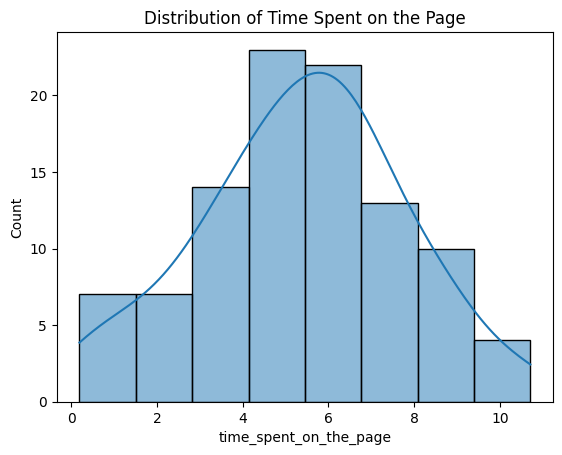

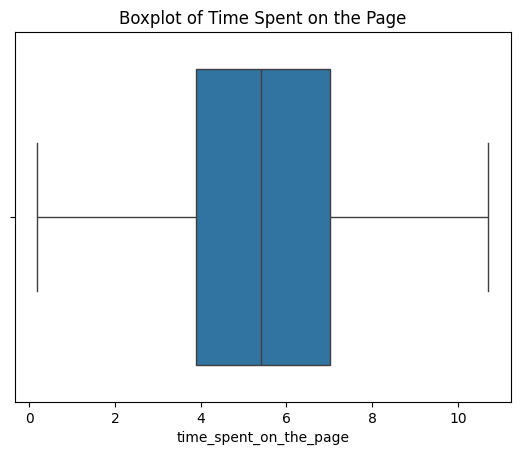

In [ ]:


# Histogram
sns.histplot(data=df, x='time_spent_on_the_page', kde=True)
plt.title("Distribution of Time Spent on the Page")
plt.show()

# Boxplot
sns.boxplot(data=df, x='time_spent_on_the_page')
plt.title("Boxplot of Time Spent on the Page")
plt.show()


The histogram indicates: most users stay акщь 4 to 7 minutes, with a noticeable tail up to 10 minutes. The KDE curve show a clear peak around 5 minutes, consistent with the median observed in the descriptive statistics.

The boxplot show a few very short visits (around 0.2–4 minute) while the majority of users cluster within a relatively narrow range. The median is centered within the box.

## Group (control vs treatment)

In [ ]:
# Value counts
df['group'].value_counts()


,count
group,
control,50
treatment,50


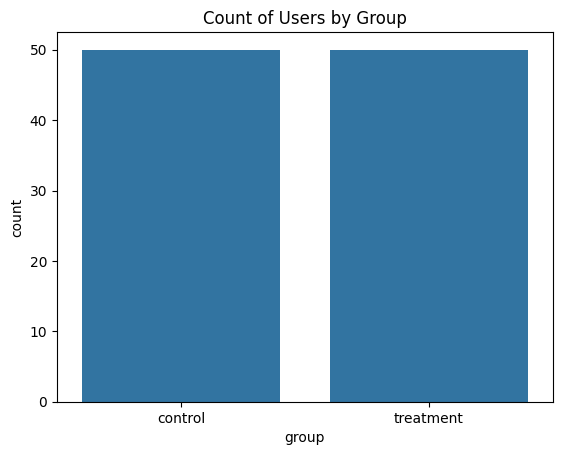

In [ ]:
# Countplot
sns.countplot(data=df, x='group')
plt.title("Count of Users by Group")
plt.show()


The distribution of users across the two groups is balanced: 50 users in the control group and 50 in the treatment group. This confirms that the A/B test was properly randomized. The countplot visually prove this symmetry.

## Landing page (old vs new)

In [ ]:
# Value counts
df['landing_page'].value_counts()


,count
landing_page,
old,50
new,50


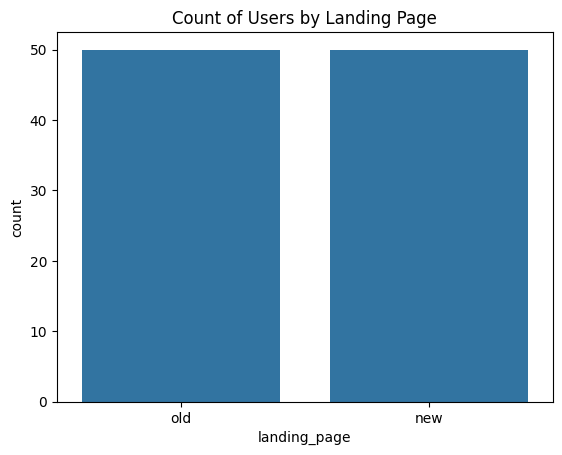

In [ ]:
# Countplot
sns.countplot(data=df, x='landing_page')
plt.title("Count of Users by Landing Page")
plt.show()


The distribution of users across the landing page versions is perfectly balanced: **50 users were shown the old page and 50 the new one.** This confirms that the experiment was executed correctly. The countplot visually shows this symmetry, ensuring **that comparisons between the two page versions are reliable.**

## Converted (yes/no)

In [ ]:
# Value counts
df['converted'].value_counts()


,count
converted,
yes,54
no,46


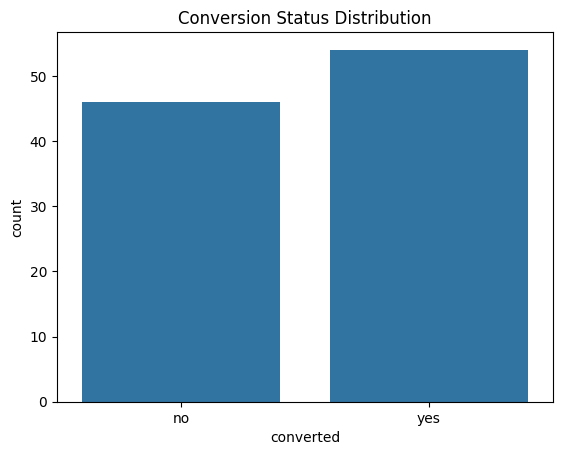

In [ ]:
# Countplot
sns.countplot(data=df, x='converted')
plt.title("Conversion Status Distribution")
plt.show()


The conversion distribution shows that **54% of users converte**d, while **46% did not**. **The countplot visually confirms a slight dominance of “yes,”** suggesting that the platform’s content is generally effective.

## Language preferred

In [ ]:
# Value counts
df['language_preferred'].value_counts()


,count
language_preferred,
Spanish,34
French,34
English,32


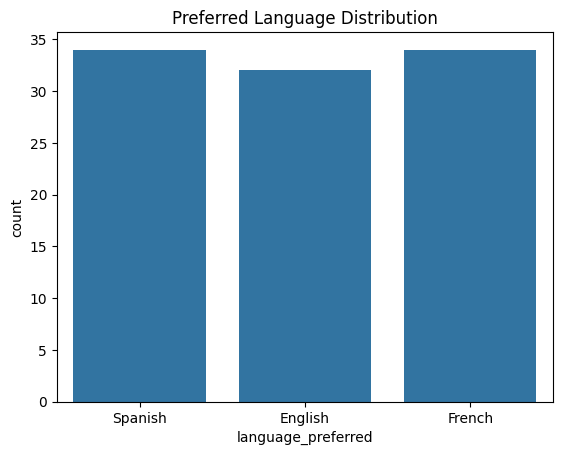

In [ ]:
# Countplot
sns.countplot(data=df, x='language_preferred')
plt.title("Preferred Language Distribution")
plt.show()


**The distribution of preferred languages** is nearly uniform
across the user base:

Spanish — 34%,

French — 34%,

English — 32%.

All three segments are well represented.

**The countplot visually confirms this balance**, which is important for analysis: the lack of language imbalance shows that hypothesis tests regarding language effects on conversion and time spent **are reliable.**

### Bivariate Analysis

We will use boxplots for bivariate analysis:

- **Landing page vs Time spent on the page** (we need to check if users spend more time on the new landing page)
- **Conversion status vs Time spent on the page** (do converted users spend more time on the page?)
- **Language preferred vs Time spent on the page** (Is time spent the same across different language groups?)




Landing page vs Time spent on the page

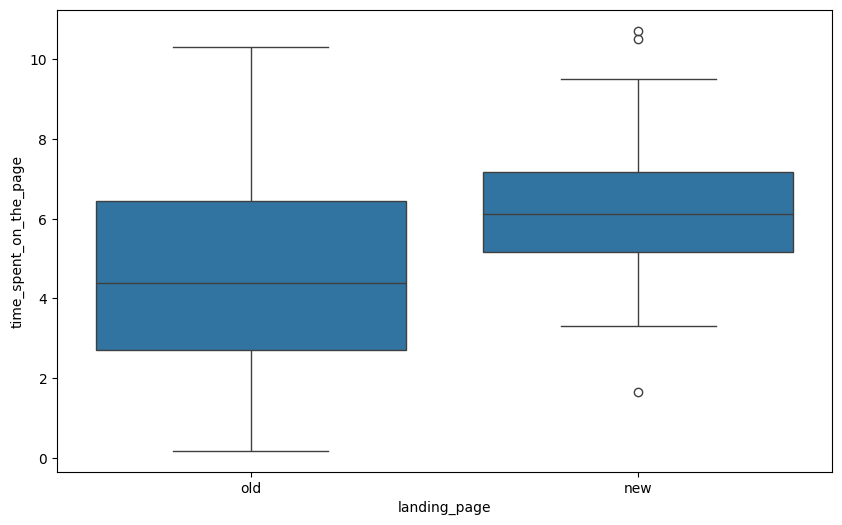

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='landing_page',y='time_spent_on_the_page')
plt.show()

The boxplot indicates that **users spend more time on the new landing page** compared to the old one.
The median time for the new page is clearly higher **(about 6 min),** and the distribution extends further toward longer visit durations.

The old page shows a lower distribution with median around 4.5 min, is less effective at keeping users engaged.

### Visually, the new page demonstrates higher user engagement.

Conversion status vs Time spent on the page

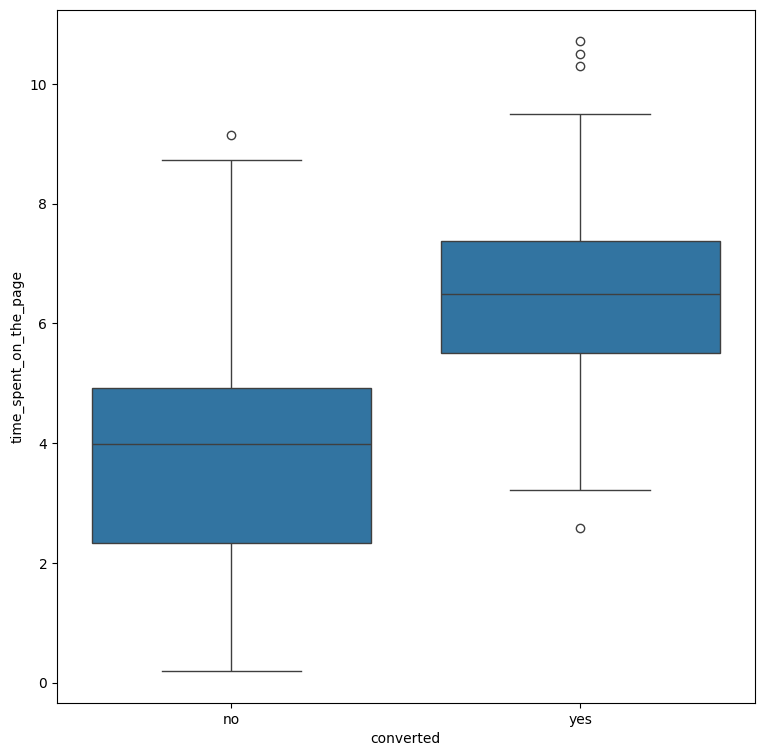

In [ ]:
# we will complete the code to plot a suitable graph to understand the relationship between 'time_spent_on_the_page' and 'converted' columns
plt.figure(figsize=(9, 9))
sns.boxplot(data = df, x = 'converted', y = 'time_spent_on_the_page')
plt.show()

The boxplot shows that **users who converted (tell "yes") tend to spend more time on the page** compared to those who did not convert.

The **median time for the "yes" group is higher (about 6.5 min)**, and the distribution is wider, indicating deeper engagement with the content.

Visually, **higher time spent on the page** is associated with a **greater tendency of conversion.**

#### Language preferred vs Time spent on the page

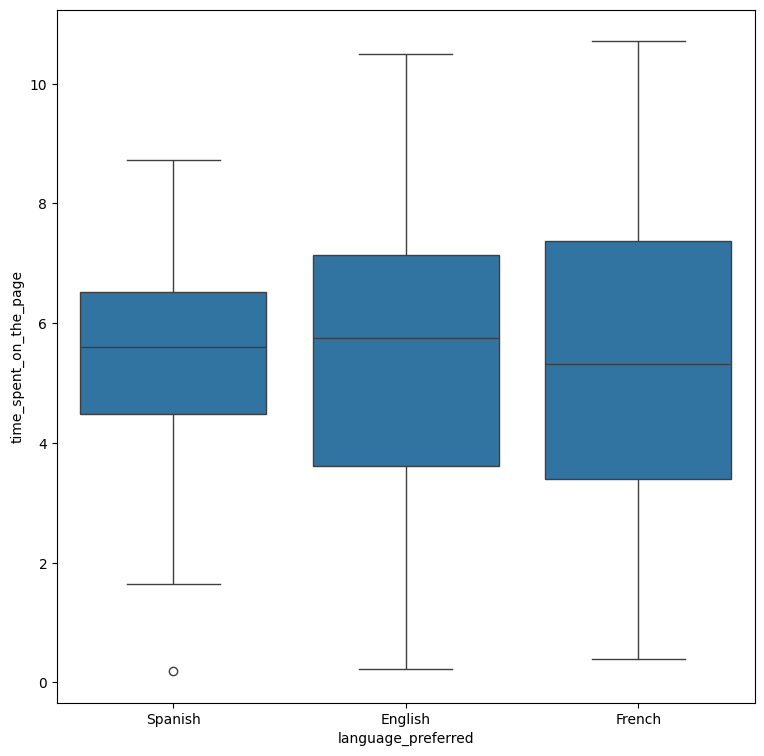

In [ ]:
# we will write the code to plot a suitable graph to understand the distribution of 'time_spent_on_the_page' among the 'language_preferred'
plt.figure(figsize=(9, 9))
sns.boxplot(data = df, x = 'language_preferred', y = 'time_spent_on_the_page')
plt.show()

The boxplot shows that the distribution of time spent on the page is **very similar across all three language groups** — English, French, and Spanish.
The medians are ***nearly aligned***,and the spread of values does not has any meaningful differences. This suggests that preferred ***language does not significantly impact user engagement***, as measured by time spent on the page.

### The boxplot shows there is no evidence that language affects time spent on the page.

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

Visual Analysis — Do users spend more time on the new landing page?

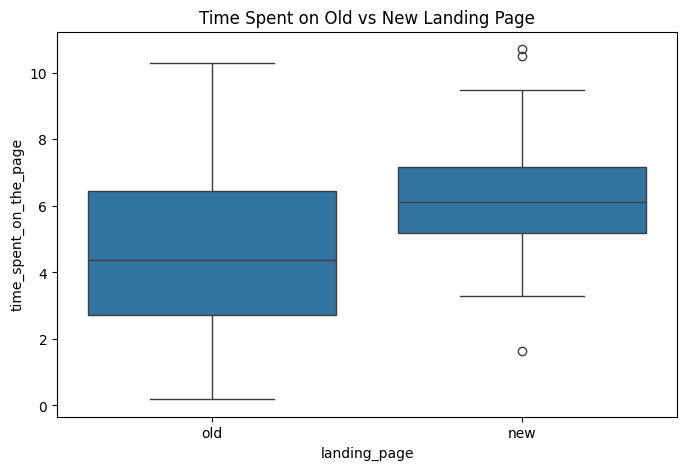

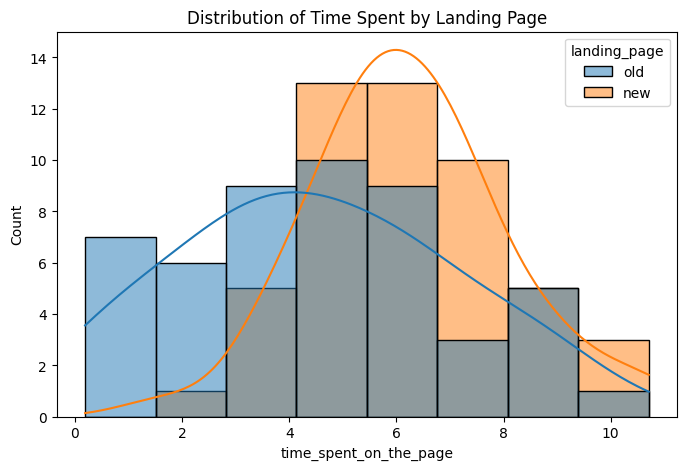

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.title("Time Spent on Old vs New Landing Page")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='time_spent_on_the_page', hue='landing_page', kde=True)
plt.title("Distribution of Time Spent by Landing Page")
plt.show()


Both the boxplot and histogram clearly indicate that **users spend more time on the new landing page** compared to the old one.

### Boxplot
The median time for the new page is **noticeably higher (around 6 min).**


### Histogram
The KDE curve for the new page shifts to the right — toward longer visit durations.

More users spend 6–10 minutes on the new page, while the old page clusters around 3–5 minutes.

This shows that the new design keeps users engaged for longer.

### **The new landing page drives higher user engagement in terms of time spent.**

### Step 1: Define the null and alternate hypotheses

### H0: Mean time spent on the new page = mean time spent on the old page

### Ha: Mean time spent on the new page > mean time spent on the old page


### Step 2: Select Appropriate test

Since we are comparing two independent groups (old and new) and the variable is numerical:

If normality is satisfied → Independent two‑sample t‑test (one‑tailed)

We will check normality using Shapiro test:

In [ ]:
from scipy.stats import shapiro

old = df[df['landing_page']=='old']['time_spent_on_the_page']
new = df[df['landing_page']=='new']['time_spent_on_the_page']

print("Shapiro old:", shapiro(old))
print("Shapiro new:", shapiro(new))


Shapiro old: ShapiroResult(statistic=np.float64(0.9776091375280825), pvalue=np.float64(0.45612796144138584))
Shapiro new: ShapiroResult(statistic=np.float64(0.9857665382791863), pvalue=np.float64(0.8040040364746845))


p‑value > 0.05 → normality is not violated.

If normality is satisfied.  **Independent two‑sample t‑test (one‑tailed).**

### Step 3: Decide the significance level

As given in the problem statement, we select  α=0.05 .

In [ ]:
alpha = 0.05


### Step 4: Collect and prepare data

In [ ]:
old = df[df['landing_page']=='old']['time_spent_on_the_page']
new = df[df['landing_page']=='new']['time_spent_on_the_page']

Based on the sample standard deviations of the two groups, decide whether the population standard deviations can be assumed to be equal or unequal.

### Step 5: Calculate the p-value

In [ ]:
from scipy.stats import ttest_ind

# one-tailed test → alternative = 'greater'
t_stat, p_value = ttest_ind(new, old, alternative='greater')

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 3.7867702694199856
p-value: 0.0001316123528095005


### Step 6: Compare the p-value with $\alpha$

In [ ]:
if p_value < alpha:
    print("Reject H0: Users spend MORE time on the new page.")
else:
    print("Fail to reject H0: No evidence that users spend more time on the new page.")


Reject H0: Users spend MORE time on the new page.


### Step 7:  Draw inference

Based on the visual analysis and the statistical test:

The average time spent on the new landing page ***is significantly higher*** than on the old one (~6 min).

The*** p‑value < 0.05 ***confirms that the difference is not due to random chance.

***The new page keeps users engaged for a longer period,*** which may increase the likelihood of conversion.

### Business Conclusion:  
***The new landing page provides an improved user experience and increases engagement.*** This is a strong argument in favor of rolling it out to all users.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

## Visual Analysis

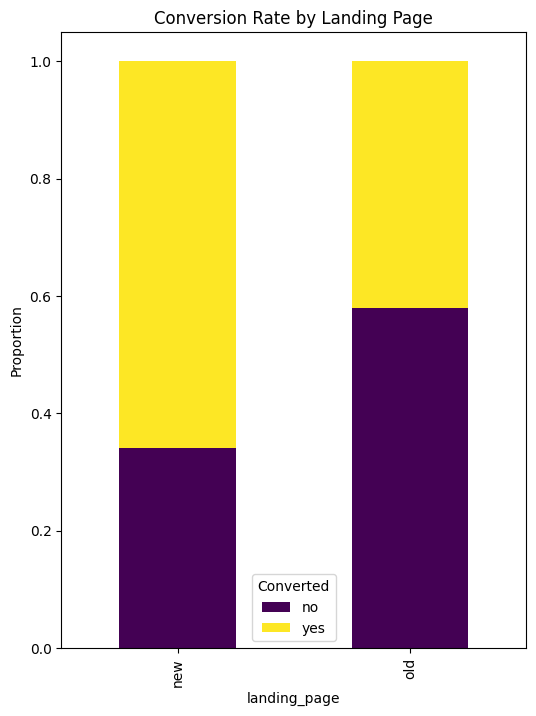

In [ ]:
# we will use visual comparison of conversion rates for old vs new page
pd.crosstab(df['landing_page'], df['converted'], normalize='index').plot(
    kind="bar", figsize=(6,8), stacked=True, colormap='viridis'
)
plt.title("Conversion Rate by Landing Page")
plt.ylabel("Proportion")
plt.legend(title="Converted")
plt.show()


The proportion of ***“yes” conversions is visually higher*** for the new landing page compared to the old one.

The old page shows noticeably more users who did not convert.

The difference appears substantial, but visualization alone does not prove statistical significance — a proportion test is required.

## Step 1: Define the hypotheses

In [ ]:
# H0: Conversion rate (new page) ≤ Conversion rate (old page)
# Ha: Conversion rate (new page) > Conversion rate (old page)


## Step 2: Select Appropriate Test

This is a one-tailed test concerning two population proportions from two independent populations.

## Two-sample proportions z-test

## Step 3: Significance level
As given in the problem statement, we select α = 0.05.

In [ ]:
alpha = 0.05


# Step 4: Collect and prepare data

In [ ]:
# number of converted users in treatment (new page)
new_converted = df[df['group'] == 'treatment']['converted'].value_counts()['yes']

# number of converted users in control (old page)
old_converted = df[df['group'] == 'control']['converted'].value_counts()['yes']

# total users in each group
n_control = df.group.value_counts()['control']
n_treatment = df.group.value_counts()['treatment']

print('Converted on NEW page:', new_converted)
print('Converted on OLD page:', old_converted)
print('Users served NEW and OLD pages:', n_treatment, n_control)


Converted on NEW page: 33
Converted on OLD page: 21
Users served NEW and OLD pages: 50 50


## Step 5: Calculate the p-value

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# one-tailed test ,  alternative = 'larger'
test_stat, p_value = proportions_ztest(
    [new_converted, old_converted],
    [n_treatment, n_control],
    alternative='larger'
)

print("Test statistic:", test_stat)
print("p-value:", p_value)


Test statistic: 2.4077170617153842
p-value: 0.008026308204056278


## Step 6: Compare the p-value with α

In [ ]:
if p_value < 0.05:
    print(f"As the p-value {p_value} is less than 0.05, we reject the null hypothesis.")
else:
    print(f"As the p-value {p_value} is greater than 0.05, we fail to reject the null hypothesis.")


As the p-value 0.008026308204056278 is less than 0.05, we reject the null hypothesis.


# Step 7: Final Inference (INSIGHT)

### Conversion on the new landing page is higher than on the old one.

The proportion test shows a p‑value < 0.05, indicating that the difference in conversion rates is statistically significant rather than random.

The new page leads to a higher number of subscribers compared to the old version.

This confirms that the updated design and content positively influence the user’s decision to subscribe.

### Business Conclusion:  
The new landing page demonstrates **a better conversion rate**, and rolling it out to all users **may increase the number of new subscribers.**

## 3. Is the conversion and preferred language are independent or related?

## Perform Visual Analysis

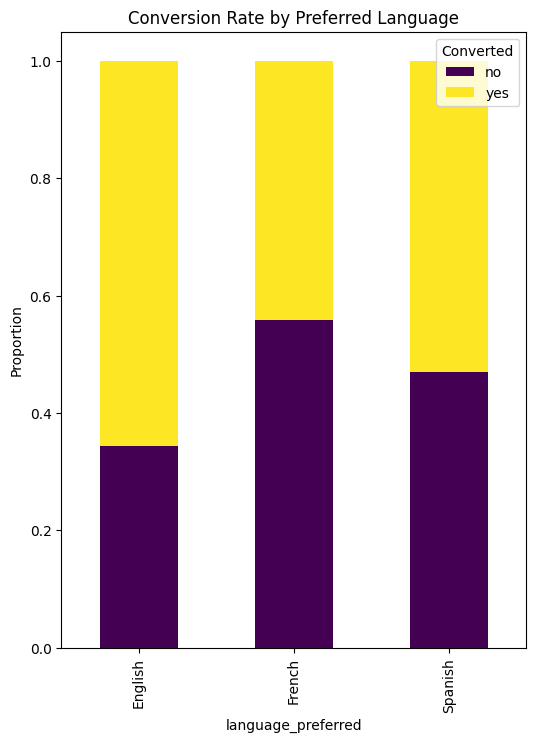

In [ ]:
# Visualizing dependency between conversion status and preferred language
pd.crosstab(df['language_preferred'], df['converted'], normalize='index').plot(
    kind="bar", figsize=(6,8), stacked=True, colormap='viridis'
)
plt.title("Conversion Rate by Preferred Language")
plt.ylabel("Proportion")
plt.legend(title="Converted")
plt.show()


Different language groups show different conversion proportions.

### Users who prefer English appear to have a higher number of “yes” conversions.

The French and Spanish groups visually show lower conversion rates.

However, visual analysis alone does not prove dependency —

### a χ² test is required.

## Step 1: Define the null and alternate hypotheses

In [ ]:
# H0: Conversion status is independent of preferred language.
# Ha: Conversion status depends on preferred language.


## Step 2: Select Appropriate Test

This is a problem of the test of independence, concerning **two categorical variables** - converted status and preferred language

**Chi-square test of independence**

# Step 3: Decide the significance level

As given in the problem statement, we select α = 0.05.

In [ ]:
alpha = 0.05


## Step 4: Collect and prepare data

In [ ]:
# Creating contingency table
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])
contingency_table


converted,no,yes
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


## Step 5: Calculate the p-value

In [ ]:
from scipy.stats import chi2_contingency

# Chi-square test
chi2, p_value, dof, exp_freq = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", exp_freq)
print("The p-value is", p_value)


Chi-square statistic: 3.0930306905370832
Degrees of freedom: 2
Expected frequencies:
 [[14.72 17.28]
 [15.64 18.36]
 [15.64 18.36]]
The p-value is 0.2129888748754345


## Step 6: Compare the p-value with α

In [ ]:
if p_value < 0.05:
    print(f"As the p-value {p_value} is less than 0.05, we reject the null hypothesis.")
else:
    print(f"As the p-value {p_value} is greater than 0.05, we fail to reject the null hypothesis.")


As the p-value 0.2129888748754345 is greater than 0.05, we fail to reject the null hypothesis.


## Step 7: Final Inference (INSIGHT)

The χ² test shows that the p‑value *is greater than 0.05.*

This indicates that there is no statistically significant relationship between language preference and conversion.

The differences observed in the visualization are likely due to random variation.

###  Conclusion:  
**Preferred language does not influence the likelihood of subscription.**
This **means that content localization across languages is not a key conversion driver,** and optimization efforts are **better focused on page design and functionality.**

## 4. Is the time spent on the new page same for the different language users?

### Perform Visual Analysis

In [ ]:
# create a new DataFrame for users who got served the new page
df_new = df[df['landing_page'] == 'new']
df_new.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
4,546459,treatment,new,4.75,yes,Spanish
6,546448,treatment,new,5.25,yes,French
8,546461,treatment,new,10.71,yes,French


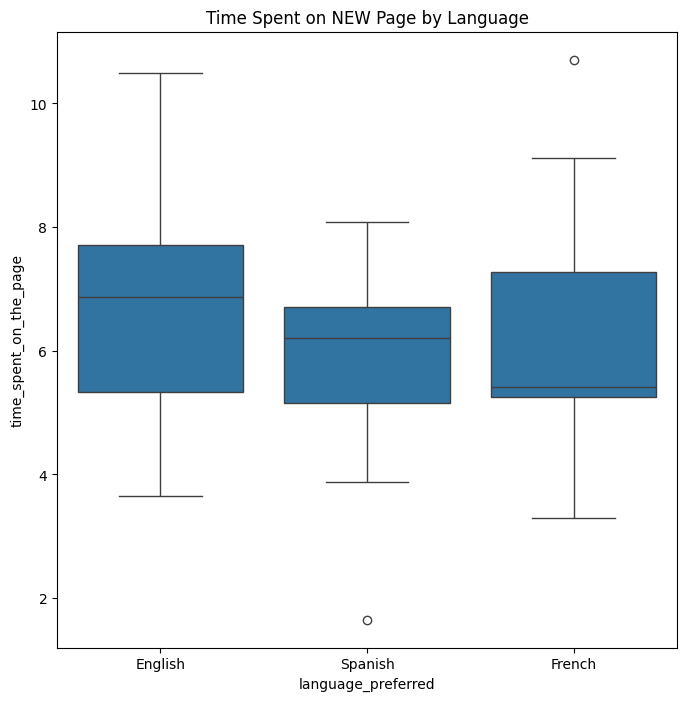

In [ ]:
# Boxplot: time spent on new page by language
plt.figure(figsize=(8,8))
sns.boxplot(x='language_preferred',
            y='time_spent_on_the_page',
            data=df_new)
plt.title("Time Spent on NEW Page by Language")
plt.show()



The medians for English, French, and Spanish ***do not align.***

The French group shows **a wider spread of time** spent.

The English group appears more stable.

The Spanish group includes several short visits.

Visually,

**the time spent seems different across groups,**

 but a statistical test is required.

## Mean time spent by language

In [ ]:
df_new.groupby(['language_preferred'])['time_spent_on_the_page'].mean()


,time_spent_on_the_page
language_preferred,
English,6.663750
French,6.196471
Spanish,5.835294


### The average time differs across the language groups.

However, differences in means alone do not prove statistical significance. **ANOVA is required.**

## Step 1: Define the null and alternate hypotheses

In [ ]:
# H0: Mean time spent on the new page is the SAME for all language groups.
# Ha: At least one language group has DIFFERENT mean time spent on the new page.


## Step 2: Select Appropriate Test

This is a problem, concerning *three population means.*

**One-way ANOVA** test.

## Step 3: Decide the significance level

As given in the problem statement, we select α = 0.05.

In [ ]:
alpha = 0.05


## Step 4: Collect and prepare data

In [ ]:
# English users
time_spent_English = df_new[df_new['language_preferred']=="English"]['time_spent_on_the_page']

# French users
time_spent_French = df_new[df_new['language_preferred']=="French"]['time_spent_on_the_page']

# Spanish users
time_spent_Spanish = df_new[df_new['language_preferred']=="Spanish"]['time_spent_on_the_page']


## Step 5: Calculate the p-value

In [ ]:
from scipy.stats import f_oneway

# One-way ANOVA
test_stat, p_value = f_oneway(time_spent_English, time_spent_French, time_spent_Spanish)

print("F-statistic:", test_stat)
print("The p-value is", p_value)


F-statistic: 0.8543992770006822
The p-value is 0.43204138694325955


## Step 6: Compare the p-value with  α

In [ ]:
if p_value < 0.05:
    print(f"As the p-value {p_value} is less than 0.05, we reject the null hypothesis.")
else:
    print(f"As the p-value {p_value} is greater than 0.05, we fail to reject the null hypothesis.")


As the p-value 0.43204138694325955 is greater than 0.05, we fail to reject the null hypothesis.


## Step 7: Draw inference

ANOVA test indicates that:

The p‑value is > 0.05.
### This means there are no statistically significant differences in the time spent on the new page across different language groups.

The differences observed in the visualization are driven by random variation, not by a real effect of language.

### Conclusion:  
### Preferred language does not influence how much time users spend on the new page.
This means the new page performs **equally well** for all language groups, and there is no need to tailor its design to any specific language.

## Conclusion and Business Recommendations

# Conclusion
Based on the analysis of the A/B test data, the following conclusions can be drawn:

1. ### The new landing page keeps users engaged for a longer time.  
The statistical test (one‑tailed t‑test) showed that users spend significantly more time on the new page compared to the old one. This indicates that the updated design and content increase user engagement.

2. ### The new page has a higher conversion rate.  
The proportion test (one‑tailed z‑test) confirmed that the conversion rate on the new page is significantly higher than on the old one. The new page is more effective at turning visitors into subscribers.

3. ### Conversion does not depend on preferred language.  
The chi‑square test showed no statistically significant relationship between the user’s language and the likelihood of conversion. This means that the interface language does not influence the decision to subscribe.

4. ### Time spent on the new page is consistent across language groups.  
ANOVA showed that the average time spent on the new page does not differ between users who prefer English, French, or Spanish. The new page performs equally well across all segments.

# Business Recommendations:
### 1. Fully roll out the new landing page.

It demonstrates improved performance across **two key metrics:**

- engagement (time on page)

- conversion rate.

This directly contributes to an increase in the number of subscribers.

### 2. Focus on optimizing content rather than language.

Since language does not affect either conversion or time on page:

- there is no need to create separate design versions for different languages.

- resources are better allocated to improving User Experience, Call to Action elements, and content personalization.

### 3. Continue A/B experiments with elements of the new page.


*It is recommended to test:*

- different Call to Action variations

- text length

- placement of key content blocks

- personalized article recommendations.

These experiments can further increase conversion.

### 4. Implement a monitoring system for key metrics.


*After launching the new page, it is important to track:*

- conversion rate

- time on page

- depth of engagement (pages per session).

This will allow timely responses to changes in user behavior.

### 5. Consider content personalization based on interests rather than language.

Since language does not influence user behavior, but interests do,
personalized article recommendations and tailored content blocks can increase engagement.


___